# Compare Trained Models (Laptop)

In [ ]:
import importlib.util
import sys
import subprocess

if importlib.util.find_spec('ultralytics') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-U', 'ultralytics'])

if importlib.util.find_spec('pandas') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-U', 'pandas'])

if importlib.util.find_spec('matplotlib') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-U', 'matplotlib'])


In [2]:
from pathlib import Path
from ultralytics import YOLO, RTDETR
import torch
import pandas as pd
import time
import matplotlib.pyplot as plt

DATA_YAML = 'data.yaml'
IMG_SIZE = 640
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

# Ubah path sesuai hasil training Anda
MODELS = {
    'yolo11': 'runs/train/lele_v1/weights/best.pt',
    'yolo26': 'runs/detect/runs/train/yolo26_lele-2/weights/best.pt',
    'rtdetr': 'runs/detect/runs/train/rtdetr_lele-2/weights/best.pt'
}


In [3]:
def load_model(path):
    path = str(path)
    if 'rtdetr' in path.lower():
        return RTDETR(path)
    return YOLO(path)

def evaluate_model(name, model_path):
    if not Path(model_path).exists():
        return {
            'model': name,
            'path': model_path,
            'status': 'missing'
        }
    model = load_model(model_path)

    # Validation on test split
    val = model.val(data=DATA_YAML, imgsz=IMG_SIZE, split='test', device=DEVICE)

    metrics = val.results_dict

    # Simple inference timing (ms/image)
    test_dir = Path('dataset_split/test/images')
    imgs = sorted(test_dir.glob('*.jpg'))[:50]  # sample 50 images
    if not imgs:
        return {
            'model': name,
            'path': model_path,
            'status': 'no_test_images'
        }

    # warmup
    _ = model.predict(source=str(imgs[0]), imgsz=IMG_SIZE, device=DEVICE, verbose=False)

    start = time.time()
    for p in imgs:
        _ = model.predict(source=str(p), imgsz=IMG_SIZE, device=DEVICE, verbose=False)
    total = time.time() - start
    ms_per_img = (total / len(imgs)) * 1000

    return {
        'model': name,
        'path': model_path,
        'status': 'ok',
        'mAP50': metrics.get('metrics/mAP50(B)', None),
        'mAP50-95': metrics.get('metrics/mAP50-95(B)', None),
        'precision': metrics.get('metrics/precision(B)', None),
        'recall': metrics.get('metrics/recall(B)', None),
        'ms_per_image': ms_per_img
    }

results = []
for name, path in MODELS.items():
    results.append(evaluate_model(name, path))

df = pd.DataFrame(results)
df


Ultralytics 8.4.51  Python-3.10.20 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 10.321.9 ms, read: 2.10.4 MB/s, size: 19.4 KB)
val: Scanning D:\Kuliah\Skripsi\model-dataset-2-kelas\dataset_split\test\labels... 144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144 322.7it/s 0.4s0.1s
val: D:\Kuliah\Skripsi\model-dataset-2-kelas\dataset_split\test\images\lele 6-1_000049_jpg.rf.mAKsYMCuWsZHOjl0OzWc.jpg: 1 duplicate labels removed
val: New cache created: D:\Kuliah\Skripsi\model-dataset-2-kelas\dataset_split\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 4.5it/s 2.0s0.2ss
                   all        144        144      0.999          1      0.995      0.857
                normal        100        100          1          1      0.995      0.849
   

,model,path,status,mAP50,mAP50-95,precision,recall,ms_per_image
0,yolo11,runs/train/lele_v1/weights/best.pt,ok,0.995000,0.856726,0.998712,1.000000,13.315935
1,yolo26,runs/detect/runs/train/yolo26_lele-2/weights/b...,ok,0.994134,0.868103,0.984318,0.982451,13.146515
2,rtdetr,runs/detect/runs/train/rtdetr_lele-2/weights/b...,ok,0.995000,0.880744,0.998257,1.000000,32.097960


In [ ]:
df.to_csv('compare_results_laptop.csv', index=False)
print('Saved: compare_results_laptop.csv')


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

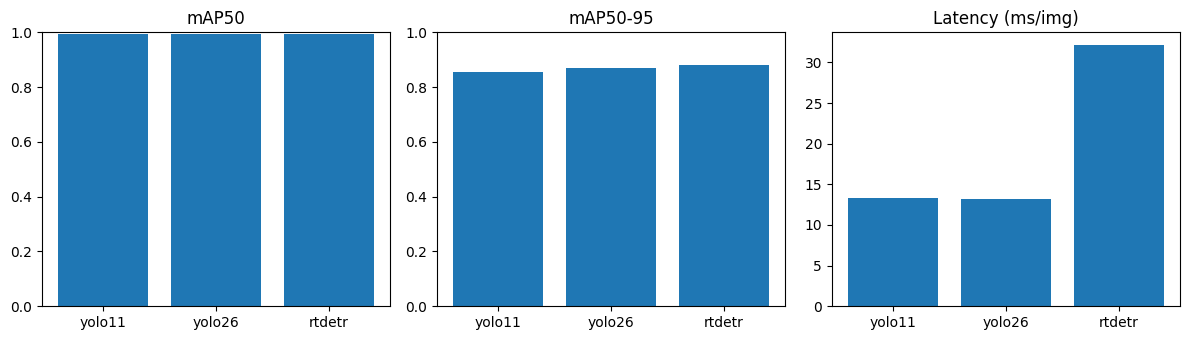

In [ ]:
plot_df = df[df['status'] == 'ok'].copy()
if plot_df.empty:
    print('No valid results to plot.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    axes[0].bar(plot_df['model'], plot_df['mAP50'])
    axes[0].set_title('mAP50')
    axes[0].set_ylim(0, 1)

    axes[1].bar(plot_df['model'], plot_df['mAP50-95'])
    axes[1].set_title('mAP50-95')
    axes[1].set_ylim(0, 1)   

    axes[2].bar(plot_df['model'], plot_df['ms_per_image'])
    axes[2].set_title('Latency (ms/img)')

    plt.tight_layout()
    plt.show()
